In [6]:
%matplotlib widget
from datetime import datetime, timedelta
import glob
from eigsep_observing import io
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import matplotlib.dates as mdates

In [17]:
DATA_DIR = "/home/eigsep/eigsep/data"
files = sorted(glob.glob(f"{DATA_DIR}/corr_20260718_02*.h5"))
files = np.array(files)
print(len(files))
hdr = io.read_hdf5(files[0])[1]
print(hdr.keys())
_data, hdr, metadata = io.read_hdf5(files[0])
print(_data.keys())
print(_data['0'].shape)

25
dict_keys(['acc_bins', 'adc_gain', 'adc_mux_sel', 'adc_snapshot_period_s', 'avg_even_odd', 'corr_acc_len', 'corr_scalar', 'corr_word', 'dfreq', 'diagnostics_period_s', 'dtype', 'fft_shift', 'fpg_file', 'header_upload_unix', 'imu_calibration_upload_unix', 'integration_time', 'linear_range_file', 'nchan', 'obs_config_owner', 'obs_config_owner_uploaded_unix', 'run_started_at_unix', 'run_tag', 'sample_rate', 'snap_ip', 'sync_time', 'tapcp_timeout_s', 'upload_time', 'use_noise', 'use_ref', 'acc_cnt', 'fpg_version', 'freqs', 'imu_calibration', 'input_to_ant', 'obs_config', 'pairs', 'pol_delay', 'redis', 'times', 'wiring'])
dict_keys(['0', '02', '04', '1', '13', '15', '2', '24', '3', '35', '4', '5'])
(240, 1024)


In [18]:
def get_dat(fname, key, missed=0):
    try:
        d = io.read_hdf5(fname)[0][key]
    except Exception:
        dtype = "float" if len(key) == 1 else "complex"
        d = np.zeros((240, 1024)).astype(dtype)
        missed += 1
    if missed > 0:
        print(missed)
    return d

In [19]:
times = np.arange(len(_data["0"]))
freqs = hdr["freqs"]

d0 = [get_dat(files[i], "0") for i in range(len(files))]
d0 = np.array(d0).reshape(-1, len(freqs))
d4 = np.array([get_dat(files[i], "4") for i in range(len(files))]).reshape(-1, len(freqs))
d04 = np.array([get_dat(files[i], "04") for i in range(len(files))]).reshape(-1, len(freqs))

In [20]:
extent = [freqs.min(), freqs.max(), len(d0), 0]
kwargs = {"aspect": "auto", "cmap": "plasma", "extent": extent, "interpolation": "none"}

/tmp/ipykernel_774101/633369568.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(d0), **kwargs, vmin=4, vmax=6.6)
/tmp/ipykernel_774101/633369568.py:2: RuntimeWarning: invalid value encountered in log10
  plt.imshow(np.log10(d0), **kwargs, vmin=4, vmax=6.6)


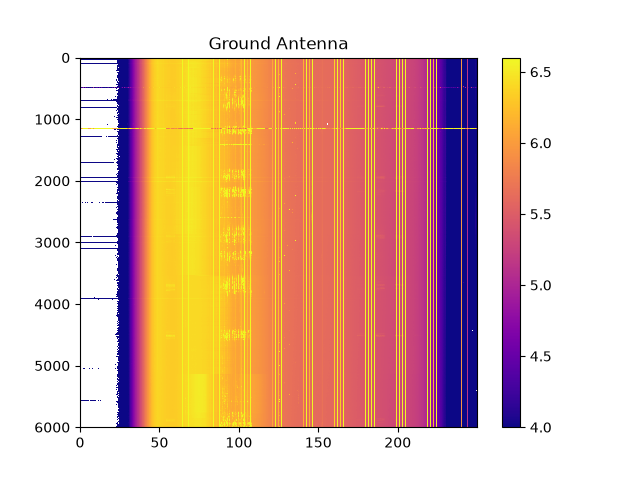

In [21]:
plt.figure()
plt.imshow(np.log10(d0), **kwargs, vmin=4, vmax=6.6)
plt.colorbar()
plt.title("Ground Antenna")
plt.show()

/tmp/ipykernel_774101/875280576.py:2: RuntimeWarning: divide by zero encountered in log10
  plt.imshow(np.log10(np.abs(np.diff(d4[-100:]))), **kwargs, vmin=4, vmax=5.5)


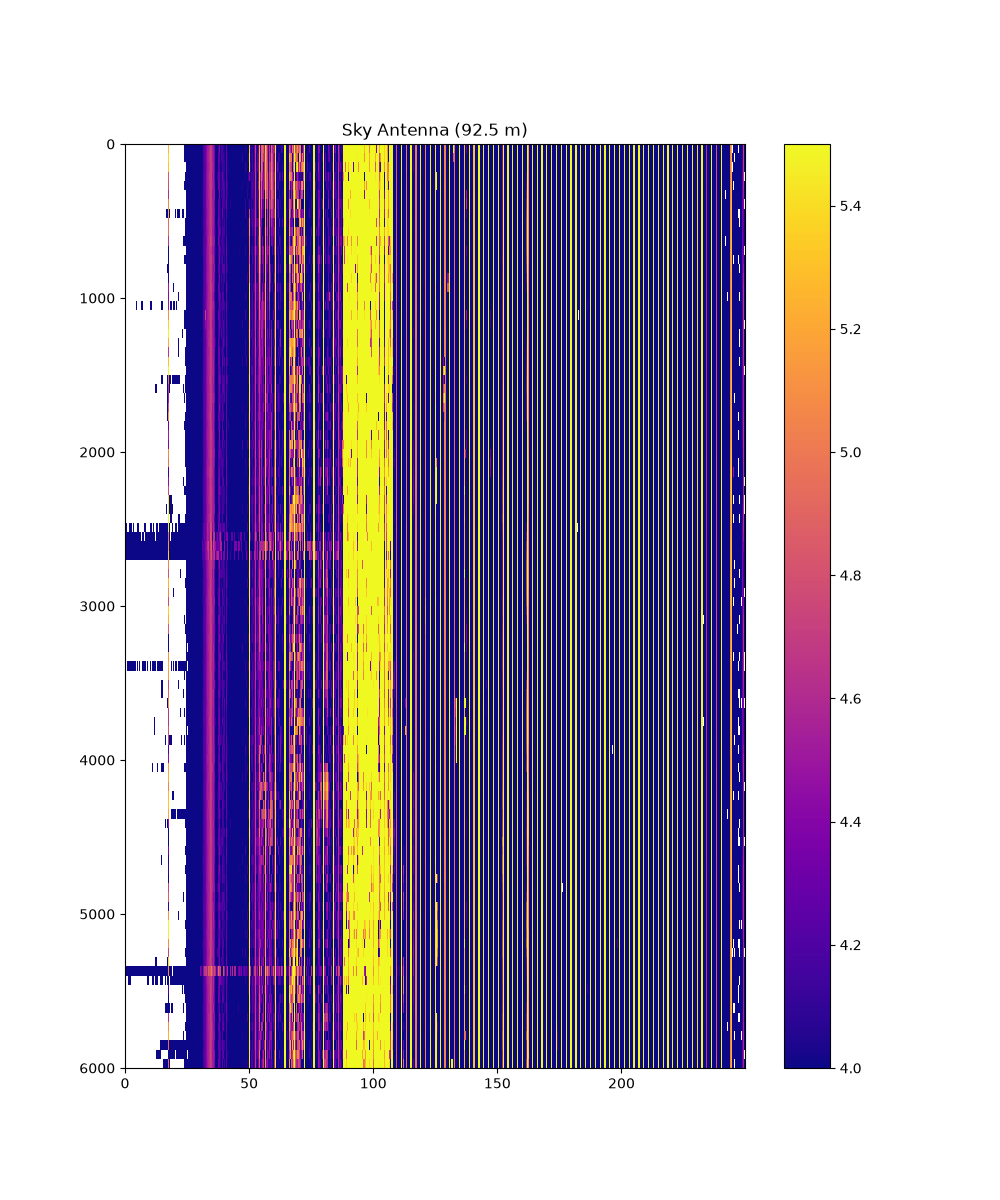

In [27]:
plt.figure(figsize=(10, 12))
plt.imshow(np.log10(np.abs(np.diff(d4[-100:]))), **kwargs, vmin=4, vmax=5.5)
plt.colorbar()
plt.title("Sky Antenna (92.5 m)")
plt.show()

/tmp/ipykernel_73087/2000180529.py:2: RuntimeWarning: divide by zero encountered in log10
  axs[0].imshow(np.log10(np.abs(d04)), **kwargs, vmin=3, vmax=6)


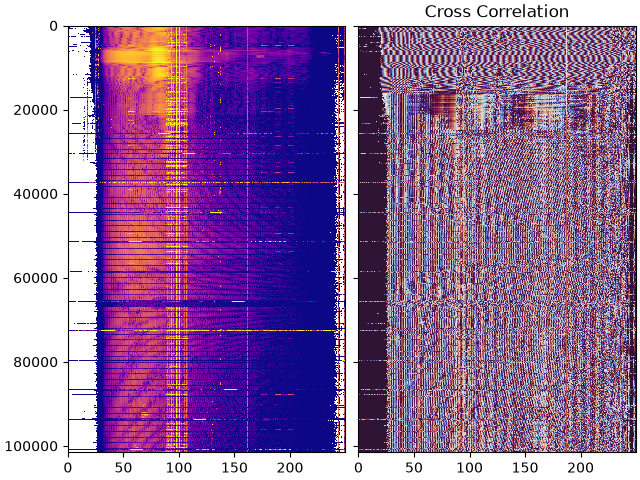

In [10]:
fig, axs = plt.subplots(ncols=2, sharex=True, sharey=True, constrained_layout=True)
axs[0].imshow(np.log10(np.abs(d04)), **kwargs, vmin=3, vmax=6)
phase_kw = {k: v for k, v in kwargs.items()}
phase_kw["cmap"] = "twilight"
axs[1].imshow(np.angle(d04), **phase_kw, vmin=-np.pi, vmax=np.pi)
plt.title("Cross Correlation")
plt.show()